## Bản Thiết Kế Tái Tạo Thực Nghiệm: Zbilut & Webber (1992)

### 1. Chuẩn Bị Dữ Liệu Đầu Vào (Data Inputs)

**A. Dữ liệu Hệ Lorenz (Động lực học xác định)**
*   **Nguồn:** Sử dụng hàm sinh hệ Lorenz có sẵn.
*   **Thông số chuẩn:** Cấu hình hàm với $\sigma=10$, $b=8/3$, $r=28$ và bước thời gian $\Delta t=0.01$.
*   **Yêu cầu đầu ra:** Lấy chính xác **2,000** điểm liên tiếp ($N_t=2000$) từ một biến trạng thái (khuyến nghị $x_1(t)$), sau khi đã loại bỏ hoàn toàn chuỗi dữ liệu chuyển tiếp (transients) ban đầu.

**B. Dữ liệu Nhiễu ngẫu nhiên (Uniform Noise)**
*   **Đặc tính:** Chuỗi số giả ngẫu nhiên phân bổ đều trên khoảng $[0, 1]$.
*   **Đầu ra:** Trích xuất chính xác **2,000** điểm dữ liệu ($N_t=2000$).

---

### 2. Thiết Lập Lưới Quét Tham Số (Parameter Sweep)

*   **Chiều nhúng ($d$):** Quét từ **1** đến **6** (bước nhảy **1**).
*   **Thời gian trễ ($\tau$):** Quét từ **1** đến **20** (bước nhảy **1**).
*   **Đo lường khoảng cách:** Sử dụng chuẩn khoảng cách Euclid trong không gian pha $\mathbb{R}^d$.
*   **Bán kính ngưỡng ($r$):**
    *   **Tính chất:** Hằng số cố định cho toàn bộ quá trình quét.
    *   **Định chuẩn:** Dựng không gian pha cơ sở tại $d=1$. Tính khoảng cách trung bình của tất cả các cặp vector. Chọn $r$ bằng hoặc nhỏ hơn **10%** giá trị trung bình này.

---

### 3. Lượng Hóa Các Chỉ Số (Quantification Metrics)

Từ ma trận hồi quy nhị phân $R_{i,j}$ (kích thước $N \times N$), hệ thống tính toán:

*   **Phần trăm hồi quy (%REC):**
    *   **Vùng tính toán:** Chỉ xét nửa tam giác trên của $R_{i,j}$ (loại bỏ hoàn toàn đường chéo chính $i=j$).
    *   **Công thức:** (Số điểm đen thực tế / Tổng số điểm tối đa trong nửa tam giác trên) $\times$ 100%.
*   **Phần trăm đoạn thẳng (%LINE):**
    *   **Vùng tính toán:** Các tập hợp điểm tạo thành đường thẳng chạy song song với đường chéo chính.
    *   **Điều kiện trích xuất:** Đoạn thẳng có độ dài tối thiểu $L_{min} \ge 2$ điểm liên tiếp.
    *   **Công thức:** (Tổng số điểm cấu thành nên các đoạn thẳng hợp lệ / Tổng số điểm đen trên toàn biểu đồ) $\times$ 100%.

---

### 4. Trực Quan Hóa Dữ Liệu (Visualizations)

Kết xuất 4 bề mặt đáp ứng 3D (3D Response Surfaces) với cấu hình trục cố định:
*   **Trục X (Hoành):** Thời gian trễ $\tau$ (**1** đến **20**).
*   **Trục Y (Tung):** Chiều nhúng $d$ (**1** đến **6**).
*   **Trục Z (Cao):** Giá trị % của chỉ số (%REC hoặc %LINE).

**Danh mục 4 đồ thị tái tạo:**
1.  **Hệ Lorenz (%REC)** (Hình 1 bài gốc).
2.  **Hệ Lorenz (%LINE)** (Hình 5 bài gốc).
3.  **Nhiễu ngẫu nhiên (%REC)** (Hình 4 bài gốc).
4.  **Nhiễu ngẫu nhiên (%LINE)** (Hình 8 bài gốc).

> **Lưu ý thực thi:** Nên áp dụng thuật toán làm mượt bề mặt (ví dụ: nội suy lưới 2D) trước khi kết xuất để đồ thị có độ cong mượt mà tương đồng với bản gốc.

---

### 5. Tiêu Chí Đối Chứng và Kiểm Thử (Validation Checkpoints)

Sử dụng ma trận hành vi này để nghiệm thu độ chính xác của thuật toán:

| Chỉ số | Hành vi Hệ Lorenz | Hành vi Nhiễu ngẫu nhiên |
| :--- | :--- | :--- |
| **%REC** | Bắt đầu tăng mạnh từ $d \ge 3$. Đạt một cực đại tương đối tại $\tau=17$ ở các chiều nhúng cao. | Bề mặt đáp ứng phẳng lặng ở mức rất thấp. Không xuất hiện cực đại hay biến động lớn. |
| **%LINE** | Xuất hiện một **đỉnh cực đại sắc nhọn (clear peak)** tại chính xác tọa độ $d=3$ và $\tau=17$. | Bề mặt duy trì ở mức phẳng và là hằng số thấp. Chỉ ghi nhận xu hướng tăng cực nhỏ khi $\tau$ tiến sát về **1**. |

In [1]:
import numpy as np
import sys
import os

sys.path.append(os.path.abspath(".."))
from core_ntsa.generators import simulate_lorenz
from core_ntsa.noise_tools import add_white_noise, add_colored_noise
from core_ntsa.recurrence_plot import run_zbilut1992 # Gọi hàm này ở bước sau

# 1. Dữ liệu Hệ Lorenz
# Tổng số điểm sinh ra: 120.0 / 0.01 = 12000 điểm
# Hàm sẽ tự động bỏ 10000 điểm đầu, trả về đúng 2000 điểm
lorenz_data = simulate_lorenz(t_span=120.0, dt=0.01, transient_drop=10000)
clean_x = lorenz_data[0] 

# Các loại nhiễu (nếu cần dùng)
x_white_noise = add_white_noise(clean_x, snr_db=10.0)
x_colored_noise = add_colored_noise(clean_x, color='pink', snr_db=10.0)

# 2. Dữ liệu Uniform Noise
# Sinh chuỗi giả ngẫu nhiên phân bố đều [0, 1] với đúng 2000 điểm
uniform_noise = np.random.uniform(0.0, 1.0, 2000)

# Kiểm tra kích thước
print(f"Kích thước Lorenz x: {len(clean_x)}")
print(f"Kích thước Uniform noise: {len(uniform_noise)}")

Kích thước Lorenz x: 2000
Kích thước Uniform noise: 2000


EXPERIMENT 1: LORENZ ATTRACTOR
Initializing Zbilut & Webber (1992) Reproduction Pipeline...
Empirical radius calculated at 7.000000000000001% of baseline mean distance: 0.6459
Executing parameter sweep for topological unfolding...
Generating response surfaces...
Plotting optimal RP at %LINE Peak (d=4, τ=13) with %LINE=100.00%...


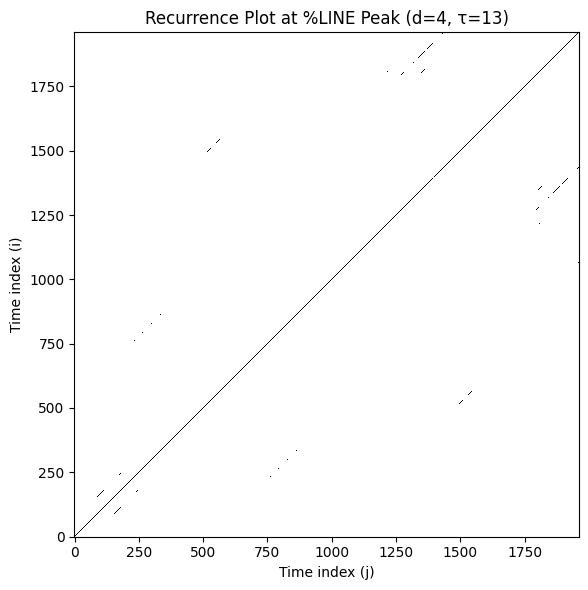

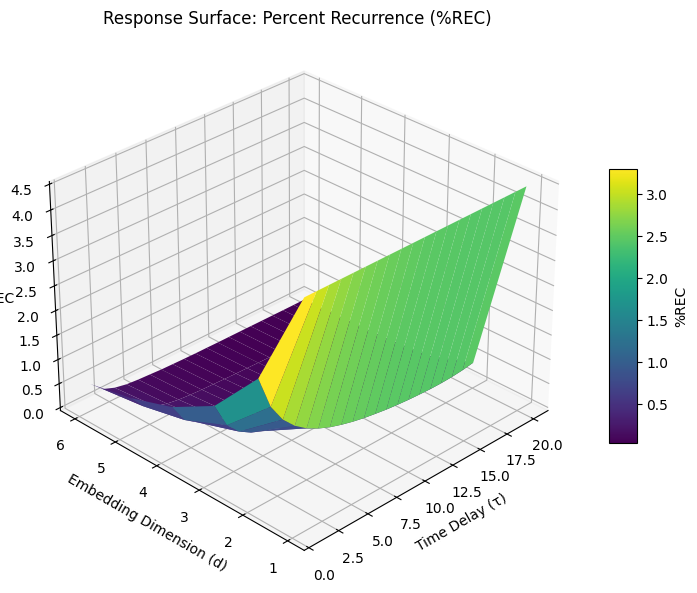

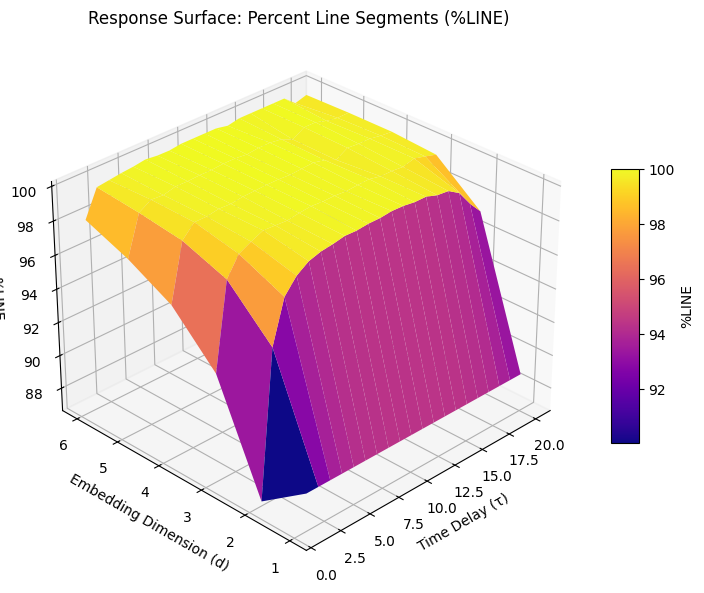

Pipeline execution complete.

EXPERIMENT 2: UNIFORM NOISE (CONTROL GROUP)
Initializing Zbilut & Webber (1992) Reproduction Pipeline...
Empirical radius calculated at 7.000000000000001% of baseline mean distance: 0.0231
Executing parameter sweep for topological unfolding...
Generating response surfaces...
Plotting optimal RP at %LINE Peak (d=1, τ=1) with %LINE=9.24%...


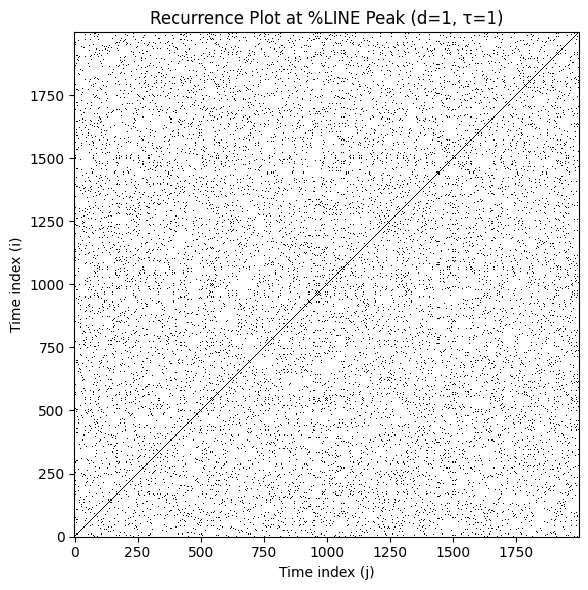

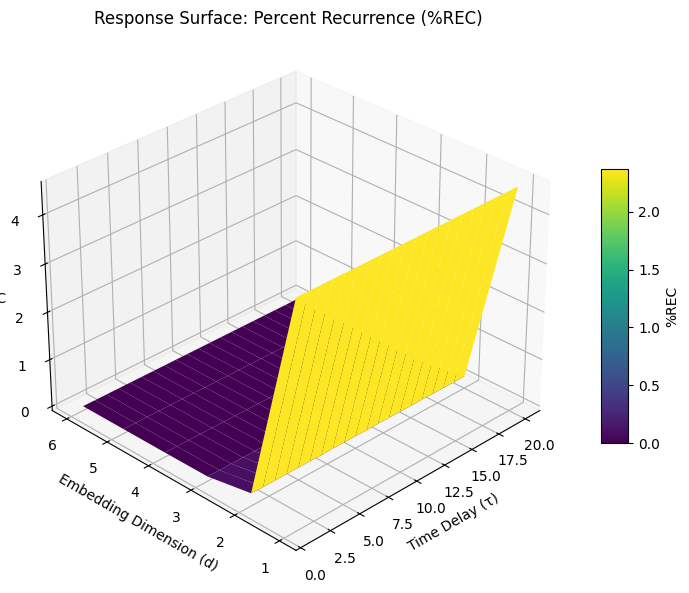

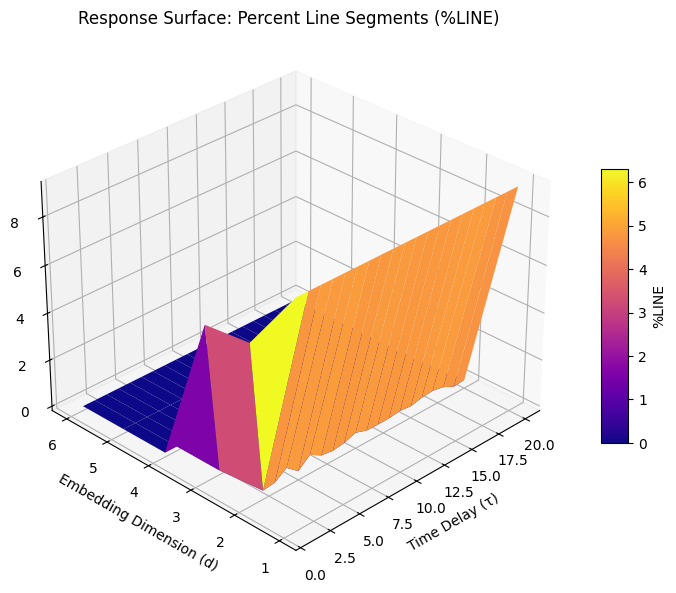

Pipeline execution complete.

All experiments completed successfully.


In [4]:
d_list = list(range(1, 7))     # d = [1, 2, 3, 4, 5, 6]
tau_list = list(range(1, 21))  # tau = [1, 2, ..., 20]

print("="*60)
print("EXPERIMENT 1: LORENZ ATTRACTOR")
print("="*60)
# Gọi hàm Wrapper. Tham số plot=True sẽ tự động lo phần vẽ 3D Surface, Heatmap 
# và in ra log cấu hình đỉnh Peak %LINE
lorenz_result = run_zbilut1992(
    u=clean_x, 
    d_list=d_list, 
    tau_list=tau_list, 
    radius_ratio=0.07, 
    plot=True
)

print("\n" + "="*60)
print("EXPERIMENT 2: UNIFORM NOISE (CONTROL GROUP)")
print("="*60)
noise_result = run_zbilut1992(
    u=uniform_noise, 
    d_list=d_list, 
    tau_list=tau_list, 
    radius_ratio=0.07, 
    plot=True
)

print("\nAll experiments completed successfully.")